# (Re-)Imag(in)ing Price Trends — CNN on Stock Chart Images

A simplified PyTorch replication of Jiang, Kelly & Xiu (2023), *(Re-)Imag(in)ing Price Trends*, Journal of Finance. A CNN is trained on 20-day OHLC chart images (with volume bars and a 20-day moving average) to predict whether a stock's return over the following 5 days is positive.

See the repository README for setup and data instructions.

In [1]:
import os
import re
import pandas as pd
import numpy as np
import os.path as op
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

IMAGE_WIDTH = {5: 15, 20: 60, 60: 180}
IMAGE_HEIGHT = {5: 32, 20: 64, 60: 96}

In [3]:
# Configuration
# Point DATA_DIR at the folder containing the *_images.dat and *_labels_w_delay.feather files
img_path = os.environ.get("DATA_DIR", op.join("data", "monthly_20d"))
years = sorted({
    int(match.group(1))
    for filename in os.listdir(img_path)
    if filename.endswith('_images.dat')
    for match in [re.search(r'(19\d{2}|20\d{2})', filename)]
    if match
})
window = 20

if not years:
    raise ValueError(f"No yearly image files found in {img_path}")

print(f"Using dataset years: {years[0]}-{years[-1]} ({len(years)} total)")

Using dataset years: 1993-2019 (27 total)


## Load Images and Labels (Multiple Years)

In [4]:
image_parts, label_parts = [], []

for year in years:
    imgs = np.memmap(
        op.join(img_path, f"20d_month_has_vb_[20]_ma_{year}_images.dat"),
        dtype=np.uint8, mode='r'
    ).reshape((-1, IMAGE_HEIGHT[window], IMAGE_WIDTH[window]))
    
    lbls = pd.read_feather(
        op.join(img_path, f"20d_month_has_vb_[20]_ma_{year}_labels_w_delay.feather")
    )
    
    image_parts.append(np.asarray(imgs))
    label_parts.append(lbls)
    print(f"Loaded {year}: {imgs.shape}")

images = np.concatenate(image_parts, axis=0)
label_df = pd.concat(label_parts, ignore_index=True)

# Create binary target
label_df['Ret_5d_binary'] = (label_df['Ret_5d'] > 0).astype(int)

print(f"\nTotal: {images.shape}")
print(f"Class balance: {label_df['Ret_5d_binary'].mean():.1%} positive")

Loaded 1993: (85644, 64, 60)
Loaded 1994: (94750, 64, 60)
Loaded 1995: (97707, 64, 60)
Loaded 1996: (102974, 64, 60)
Loaded 1997: (107311, 64, 60)
Loaded 1998: (106201, 64, 60)
Loaded 1999: (100284, 64, 60)
Loaded 2000: (98148, 64, 60)
Loaded 2001: (91985, 64, 60)
Loaded 2002: (85729, 64, 60)
Loaded 2003: (80894, 64, 60)
Loaded 2004: (79512, 64, 60)
Loaded 2005: (79883, 64, 60)
Loaded 2006: (80163, 64, 60)
Loaded 2007: (81140, 64, 60)
Loaded 2008: (78186, 64, 60)
Loaded 2009: (70065, 64, 60)
Loaded 2010: (68111, 64, 60)
Loaded 2011: (67325, 64, 60)
Loaded 2012: (66250, 64, 60)
Loaded 2013: (65486, 64, 60)
Loaded 2014: (67302, 64, 60)
Loaded 2015: (68827, 64, 60)
Loaded 2016: (68141, 64, 60)
Loaded 2017: (67858, 64, 60)
Loaded 2018: (68481, 64, 60)
Loaded 2019: (68637, 64, 60)

Total: (2196994, 64, 60)
Class balance: 50.3% positive


## Handle Missing Values

In [5]:
valid_mask = ~label_df['Ret_5d'].isnull()
images = images[valid_mask.values]
label_df = label_df[valid_mask].reset_index(drop=True)

print(f"Valid samples: {len(images):,}")

Valid samples: 2,190,724


## Time-Series Split (60/20/20)

Using chronological split to prevent data leakage - training data comes before validation, which comes before test.

In [6]:
# Sort by date for proper time-series split
sorted_idx = label_df.sort_values('Date').index.values
label_df = label_df.iloc[sorted_idx].reset_index(drop=True)
images = images[sorted_idx]

# Split by unique dates
unique_dates = label_df['Date'].unique()
n_dates = len(unique_dates)

train_cutoff = unique_dates[int(0.6 * n_dates) - 1]
val_cutoff = unique_dates[int(0.8 * n_dates) - 1]

train_mask = label_df['Date'] <= train_cutoff
val_mask = (label_df['Date'] > train_cutoff) & (label_df['Date'] <= val_cutoff)
test_mask = label_df['Date'] > val_cutoff

train_images, train_labels = images[train_mask], label_df[train_mask]
val_images, val_labels = images[val_mask], label_df[val_mask]
test_images, test_labels = images[test_mask], label_df[test_mask]

print(f"Train: {len(train_images):,} ({train_labels['Date'].min()} to {train_labels['Date'].max()})")
print(f"Val:   {len(val_images):,} ({val_labels['Date'].min()} to {val_labels['Date'].max()})")
print(f"Test:  {len(test_images):,} ({test_labels['Date'].min()} to {test_labels['Date'].max()})")

Train: 1,458,026 (1993-01-29 00:00:00 to 2009-02-27 00:00:00)
Val:   363,309 (2009-03-31 00:00:00 to 2014-07-31 00:00:00)
Test:  369,389 (2014-08-29 00:00:00 to 2019-12-31 00:00:00)


## Visualize Sample Images

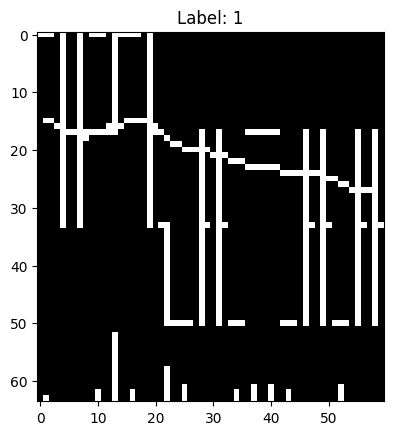

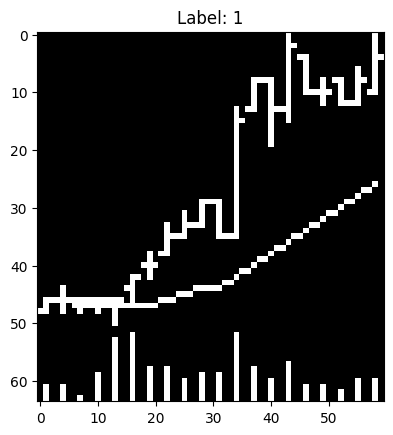

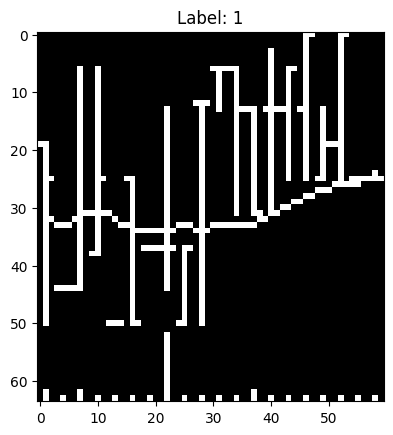

In [7]:
from matplotlib import pyplot as plt

for i in range(3):
    plt.imshow(images[i], cmap='gray')
    plt.title(f"Label: {label_df['Ret_5d_binary'].iloc[i]}")
    plt.show()

## Convolutional Neural Network

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [9]:
# Convert to PyTorch tensors and normalize to [0,1]
X_train = torch.tensor(train_images, dtype=torch.float32).unsqueeze(1) / 255.0
y_train = torch.tensor(train_labels['Ret_5d_binary'].values, dtype=torch.float32)

X_val = torch.tensor(val_images, dtype=torch.float32).unsqueeze(1) / 255.0
y_val = torch.tensor(val_labels['Ret_5d_binary'].values, dtype=torch.float32)

X_test = torch.tensor(test_images, dtype=torch.float32).unsqueeze(1) / 255.0
y_test = torch.tensor(test_labels['Ret_5d_binary'].values, dtype=torch.float32)

# Create dataloaders
batch_size = 32

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

print(f"X_train shape: {X_train.shape}")

X_train shape: torch.Size([1458026, 1, 64, 60])


In [10]:
# Define CNN model
class StockCNN(nn.Module):
    def __init__(self, dropout_rate=0.15):
        super(StockCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.conv3 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(32)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(32 * 8 * 7, 32)  # Smaller head to reduce overfitting.
        self.fc2 = nn.Linear(32, 1)
        self.dropout = nn.Dropout(dropout_rate)
        
    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))  # 64x60 -> 32x30
        x = self.pool(F.relu(self.bn2(self.conv2(x))))  # 32x30 -> 16x15
        x = self.pool(F.relu(self.bn3(self.conv3(x))))  # 16x15 -> 8x7
        x = x.view(-1, 32 * 8 * 7)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

## Hyperparameter Configuration

Experimented with the following hyperparameters:

In [11]:
# Hyperparameters (can be tuned)
learning_rate = 0.0003
dropout_rate = 0.4
num_epochs = 20
patience = 6
weight_decay = 1e-4

# Class-balance diagnostics for each split
train_pos_rate = y_train.mean().item()
val_pos_rate = y_val.mean().item()
test_pos_rate = y_test.mean().item()
n_pos = int(y_train.sum().item())
n_neg = len(y_train) - n_pos

# Initialize model, loss, and optimizer
model = StockCNN(dropout_rate=dropout_rate).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Train positive rate: {train_pos_rate:.2%}")
print(f"Val positive rate:   {val_pos_rate:.2%}")
print(f"Test positive rate:  {test_pos_rate:.2%}")
print("Loss: BCEWithLogitsLoss")

Parameters: 71,617
Train positive rate: 49.80%
Val positive rate:   52.96%
Test positive rate:  50.72%
Loss: BCEWithLogitsLoss


In [12]:
# Training loop with history tracking
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'val_f1': []}
best_val_f1 = -1.0
best_val_loss = float('inf')
patience_counter = 0
best_model_state = None

for epoch in range(num_epochs):
    # Training
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(inputs).squeeze(-1)
        loss = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()
        train_loss += loss.item()
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)
    
    # Validation
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    val_probs, val_labels_epoch = [], []
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            logits = model(inputs).squeeze(-1)
            loss = criterion(logits, labels)
            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).float()
            val_loss += loss.item()
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)
            val_probs.extend(probs.cpu().numpy())
            val_labels_epoch.extend(labels.cpu().numpy())
    
    train_loss_epoch = train_loss / len(train_loader)
    val_loss_epoch = val_loss / len(val_loader)
    train_acc_epoch = 100 * train_correct / train_total
    val_acc_epoch = 100 * val_correct / val_total
    val_f1_epoch = f1_score(np.array(val_labels_epoch), (np.array(val_probs) > 0.5).astype(int), zero_division=0)
    
    history['train_loss'].append(train_loss_epoch)
    history['val_loss'].append(val_loss_epoch)
    history['train_acc'].append(train_acc_epoch)
    history['val_acc'].append(val_acc_epoch)
    history['val_f1'].append(val_f1_epoch)
    
    improved = (val_f1_epoch > best_val_f1) or (val_f1_epoch == best_val_f1 and val_loss_epoch < best_val_loss)
    if improved:
        best_val_f1 = val_f1_epoch
        best_val_loss = val_loss_epoch
        best_model_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
        marker = " *"
    else:
        patience_counter += 1
        marker = ""
    
    print(f'Epoch {epoch+1:2d}/{num_epochs}, Loss: {train_loss_epoch:.4f}, Val Loss: {val_loss_epoch:.4f}, Val Acc: {val_acc_epoch:.2f}%, Val F1: {val_f1_epoch:.4f}{marker}')
    
    if patience_counter >= patience:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

# Load best model
if best_model_state is not None:
    model.load_state_dict(best_model_state)
print(f"\nBest validation F1: {best_val_f1:.4f}")

Epoch  1/20, Loss: 0.6844, Val Loss: 0.6892, Val Acc: 53.88%, Val F1: 0.6367 *
Epoch  2/20, Loss: 0.6792, Val Loss: 0.6914, Val Acc: 53.48%, Val F1: 0.6137
Epoch  3/20, Loss: 0.6775, Val Loss: 0.6920, Val Acc: 53.22%, Val F1: 0.5848
Epoch  4/20, Loss: 0.6762, Val Loss: 0.6930, Val Acc: 52.99%, Val F1: 0.5874
Epoch  5/20, Loss: 0.6755, Val Loss: 0.6941, Val Acc: 52.99%, Val F1: 0.5919
Epoch  6/20, Loss: 0.6747, Val Loss: 0.6924, Val Acc: 52.95%, Val F1: 0.5892
Epoch  7/20, Loss: 0.6742, Val Loss: 0.6949, Val Acc: 52.39%, Val F1: 0.5945

Early stopping at epoch 7

Best validation F1: 0.6367


## Validation Threshold Tuning

Default threshold (0.50) macro F1: 0.5027
Optimal threshold (0.52) macro F1: 0.5274


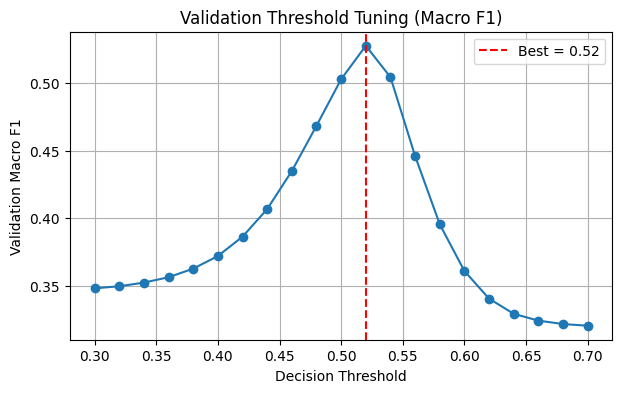

In [13]:
# Tune the classification threshold on the validation set using macro F1.
model.eval()
val_probs, val_true = [], []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        logits = model(inputs).squeeze(-1)
        probs = torch.sigmoid(logits).cpu().numpy()
        val_probs.extend(probs)
        val_true.extend(labels.numpy())

val_probs = np.array(val_probs)
val_true = np.array(val_true)
thresholds = np.arange(0.30, 0.71, 0.02)
f1_scores = [f1_score(val_true, (val_probs > t).astype(int), average='macro', zero_division=0) for t in thresholds]
best_idx = int(np.argmax(f1_scores))
optimal_threshold = float(thresholds[best_idx])

default_macro_f1 = f1_score(val_true, (val_probs > 0.5).astype(int), average='macro', zero_division=0)
print(f"Default threshold (0.50) macro F1: {default_macro_f1:.4f}")
print(f"Optimal threshold ({optimal_threshold:.2f}) macro F1: {f1_scores[best_idx]:.4f}")

plt.figure(figsize=(7, 4))
plt.plot(thresholds, f1_scores, marker='o')
plt.axvline(optimal_threshold, color='red', linestyle='--', label=f'Best = {optimal_threshold:.2f}')
plt.xlabel('Decision Threshold')
plt.ylabel('Validation Macro F1')
plt.title('Validation Threshold Tuning (Macro F1)')
plt.grid(True)
plt.legend()
plt.show()

## Training and Validation Loss Curves

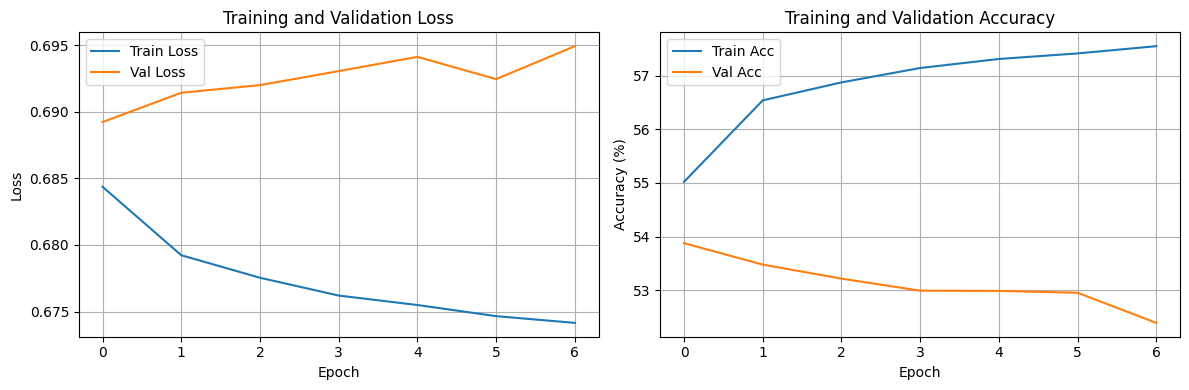

Train-Val accuracy gap: 5.16%


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss curves
axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['val_loss'], label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy curves
axes[1].plot(history['train_acc'], label='Train Acc')
axes[1].plot(history['val_acc'], label='Val Acc')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Check for overfitting
gap = history['train_acc'][-1] - history['val_acc'][-1]
print(f"Train-Val accuracy gap: {gap:.2f}%")
if gap > 10:
    print("Warning: Model may be overfitting")

## Test Evaluation

In [15]:
import seaborn as sns

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        logits = model(inputs).squeeze(-1)
        probs = torch.sigmoid(logits).cpu().numpy()
        all_probs.extend(probs)
        all_preds.extend((probs > optimal_threshold).astype(float))
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

# Metrics
print("Test Set Performance:")
print(f"  Threshold: {optimal_threshold:.2f}")
print(f"  Accuracy:  {accuracy_score(all_labels, all_preds)*100:.2f}%")
print(f"  Precision: {precision_score(all_labels, all_preds, zero_division=0):.4f}")
print(f"  Recall:    {recall_score(all_labels, all_preds, zero_division=0):.4f}")
print(f"  F1-Score:  {f1_score(all_labels, all_preds, zero_division=0):.4f}")

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=['Down', 'Up'], zero_division=0))

Test Set Performance:
  Threshold: 0.52
  Accuracy:  52.48%
  Precision: 0.5284
  Recall:    0.5876
  F1-Score:  0.5564

Classification Report:
              precision    recall  f1-score   support

        Down       0.52      0.46      0.49    182042
          Up       0.53      0.59      0.56    187347

    accuracy                           0.52    369389
   macro avg       0.52      0.52      0.52    369389
weighted avg       0.52      0.52      0.52    369389



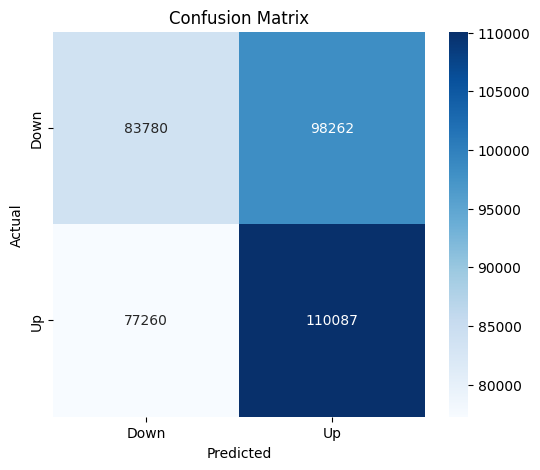

In [16]:
# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## Misclassified Examples Analysis

In [17]:
# Find misclassified samples
misclassified_idx = np.where(all_preds != all_labels)[0]
false_positives = np.where((all_preds == 1) & (all_labels == 0))[0]
false_negatives = np.where((all_preds == 0) & (all_labels == 1))[0]

print(f"Total test samples: {len(all_labels):,}")
print(f"Misclassified: {len(misclassified_idx):,} ({len(misclassified_idx)/len(all_labels)*100:.2f}%)")
print(f"  False Positives (predicted UP, actual DOWN): {len(false_positives):,}")
print(f"  False Negatives (predicted DOWN, actual UP): {len(false_negatives):,}")

# Confidence analysis
correct_mask = all_preds == all_labels
print(f"\nAvg confidence on correct predictions: {np.abs(all_probs[correct_mask] - 0.5).mean()*2:.4f}")
print(f"Avg confidence on errors: {np.abs(all_probs[~correct_mask] - 0.5).mean()*2:.4f}")

Total test samples: 369,389
Misclassified: 175,522 (47.52%)
  False Positives (predicted UP, actual DOWN): 98,262
  False Negatives (predicted DOWN, actual UP): 77,260

Avg confidence on correct predictions: 0.0863
Avg confidence on errors: 0.0799


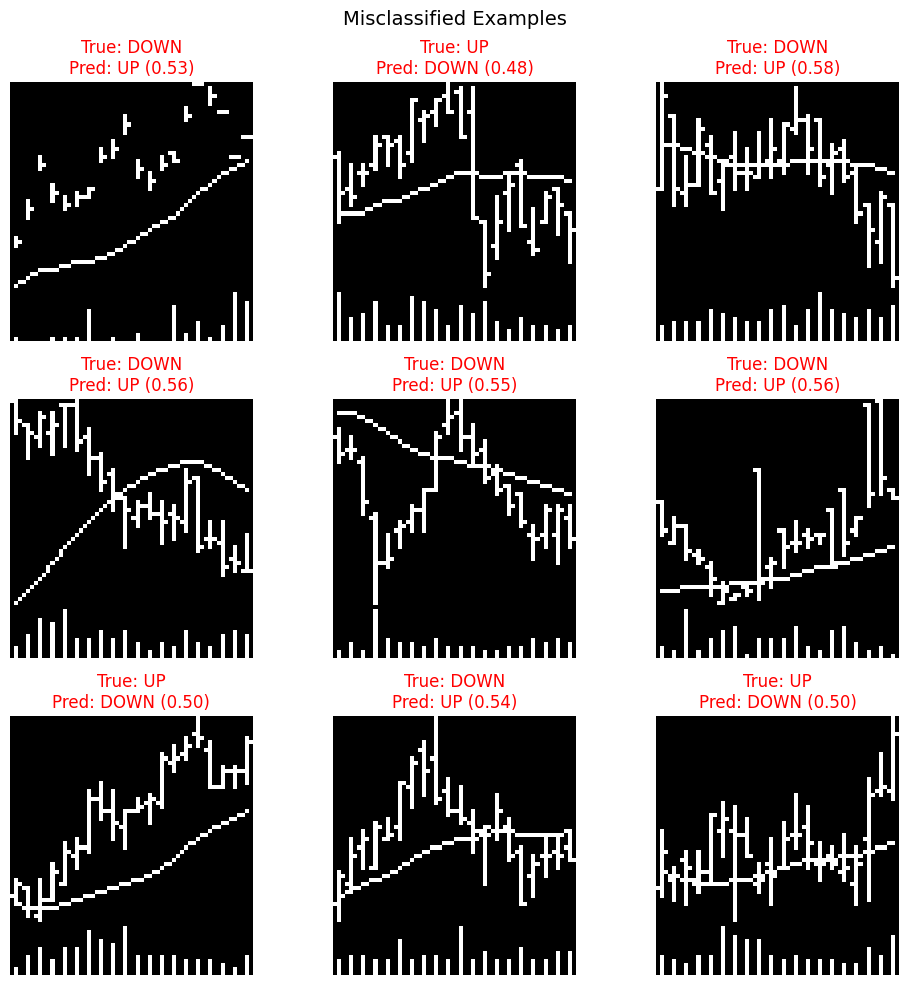

In [18]:
# Visualize misclassified examples
n_samples = min(9, len(misclassified_idx))
sample_idx = np.random.choice(misclassified_idx, n_samples, replace=False)

fig, axes = plt.subplots(3, 3, figsize=(10, 10))
axes = axes.ravel()

for i, idx in enumerate(sample_idx):
    img = X_test[idx].squeeze().numpy()
    true_label = 'UP' if all_labels[idx] == 1 else 'DOWN'
    pred_label = 'UP' if all_preds[idx] == 1 else 'DOWN'
    conf = all_probs[idx]
    
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"True: {true_label}\nPred: {pred_label} ({conf:.2f})", color='red')
    axes[i].axis('off')

plt.suptitle('Misclassified Examples', fontsize=14)
plt.tight_layout()
plt.show()

In [19]:
# Save model
torch.save(model.state_dict(), 'stock_cnn_model.pth')
print("Model saved to stock_cnn_model.pth")

Model saved to stock_cnn_model.pth
